In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, scipy
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, Dopri5, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize
from jax.experimental.ode import odeint

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.pm import linear_field, lpt, make_ode_fn, pm_forces, make_ode_fn_diffrax, make_ode_fn
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, ResNet3D, ResNetBlock3D, GraphConvolution, CNN, HybridNet, AttentionGNN
from jaxpm import camels, plotting, hpm, nn
from jaxpm.graph import jax_get_knn

# print(jax.devices("gpu"))
print(jax.default_backend())

gpu


# configuration

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

# CAMELS

In [4]:
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0"
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1"
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_2"

out_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    # i_snapshots=[-2,-1],
    # i_snapshots=range(1, 33+4, 8),
    i_snapshots=range(1, 33+4, 4),
    return_hydro=True,
)

cosmo = out_dict["cosmo"]
scales = out_dict["scales"]

dm_poss = out_dict["dm_poss"]
dm_vels = out_dict["dm_vels"]

gas_poss = out_dict["gas_poss"]
gas_vels = out_dict["gas_vels"]

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_034.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_050.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_066.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_082.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


loading snapshots: 100%|██████████| 9/9 [01:41<00:00, 11.26s/it]


In [5]:
@nnx.jit(static_argnames=("loss_fn",))
def train_step(model, optimizer, loss_fn):
    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)

    return loss

losses = []

In [16]:
def solve_ode_diffrax(model, architecture):
# def solve_ode_diffrax(model):
    res = diffeqsolve(
            terms=ODETerm(hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, integrator_type="diffrax")),
            solver=LeapfrogMidpoint(),
            t0=scales[0],
            t1=scales[-1],
            dt0=0.01,
            y0=jnp.stack([dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]], axis=0),
            saveat=SaveAt(ts=scales),
            args={},
            max_steps=100,
            stepsize_controller=ConstantStepSize(),
        )
    res = res.ys
    res = jnp.transpose(res, (1,0,2,3))
    
    return res

def solve_ode_jax(model):
    res = odeint(
        hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, force_type="table"), 
        [dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]],
        scales,
        rtol=1e-2, 
        atol=1e-2
    )

    return res

In [17]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

# loss

### CAMELS ground truth

In [18]:
# per-particle reference
ref_pos = jnp.stack(gas_poss, axis=0)
ref_vel = jnp.stack(gas_vels, axis=0)

# field-level reference
ref_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, cosmo.Omega_b / cosmo.Omega_c)

# power spectrum reference
vpower_spectrum = jax.vmap(
    lambda fields: 
        power_spectrum(
            compensate_cic(fields),
            boxsize=np.array([25.0] * 3),
            kmin=np.pi / 25.0,
            dk=2 * np.pi / 25.0,
        )
)
_, ref_cls = vpower_spectrum(ref_rho)

vcross_correlation_separate = jax.vmap(
    lambda field_a, field_b:
        cross_correlation_coefficients(
            compensate_cic(field_a),
            compensate_cic(field_b),
            boxsize=np.array([25.0] * 3),
            kmin=np.pi / 25.0,
            dk=2 * np.pi / 25.0,
        )
)
vcross_correlation = lambda rhos: vcross_correlation_separate(rhos, ref_rho)

### particle-level

In [19]:
def particle_loss_fn(model, architecture):
# def particle_loss_fn(model):
    res = solve_ode_diffrax(model, architecture)
    # res = solve_ode_diffrax(model)

    # pos_loss = jnp.sum((res[2] - ref_pos)**2, axis=-1)
    pos_loss = jnp.sum((res[2]%64 - ref_pos)**2, axis=-1)

    pos_loss = jnp.where(pos_loss < mesh_per_dim//2, pos_loss, 0.)
    # pos_loss *= jnp.expand_dims(scales, axis=1)
    pos_loss = jnp.mean(pos_loss)

    vel_loss = jnp.sum((res[3] - ref_vel)**2, axis=-1)
    vel_loss = jnp.where(vel_loss < mesh_per_dim//2, vel_loss, 0.)
    # vel_loss *= jnp.expand_dims(scales, axis=1)
    vel_loss = jnp.mean(vel_loss)

    res_rho = vcic_paint(jnp.zeros(mesh_shape), res[2], cosmo.Omega_b / cosmo.Omega_c)
    _, res_cls = vpower_spectrum(res_rho)
    cl_loss = jnp.mean(jnp.sum((res_cls/ref_cls - 1)**2, axis=-1))

    _, res_cross = vcross_correlation(res_rho)
    cross_loss = jnp.mean(jnp.sum((res_cross/jnp.sqrt(ref_cls * res_cls) - 1)**2, axis=-1))

    # return pos_loss + 0.01 * vel_loss + 0.1 * cl_loss + 1 * cross_loss
    # return cl_loss
    # return cross_loss
    return pos_loss + 0.01 * vel_loss + 0.01 * cl_loss
    # return cl_loss
    # return pos_loss + 0.01 * vel_loss
    # return pos_loss + 0.01 * vel_loss
    # return pos_loss + vel_loss
    # return pos_loss


### field-level

In [20]:
# def field_loss_fn(model):
#     res = solve_ode_diffrax(model)

#     rho = vcic_paint(jnp.zeros(mesh_shape), res[2], cosmo.Omega_b / cosmo.Omega_c)
#     rho_loss = jnp.nanmean((rho - ref_rho)**2)
    
#     # eps = 1e-5
#     # rho_loss = jnp.mean((jnp.log1p(rho + eps) - jnp.log1p(ref_rho + eps))**2)
    
#     # _, res_cls = vpower_spectrum(res_rho)
#     # cl_loss = jnp.mean(jnp.sum((res_cls/ref_cls - 1)**2, axis=-1))
    
#     return rho_loss
#     # return rho_loss + 0.1 * cl_loss


# architecture

### MLP

In [38]:
model = MLP(
    d_in=3, 
    d_out=3, 
    d_hidden=64, 
    n_hidden=4, 
    rngs=nnx.Rngs(0)
)
architecture = "mlp"

### MLP + CNN

In [39]:
# mlp = MLP(
#     d_in=3,
#     d_out=8, 
#     d_hidden=64, 
#     n_hidden=4, 
#     rngs=nnx.Rngs(0)
# )

# cnn = CNN(
#     d_in=2,
#     d_out=8,
#     d_hidden=8,
#     num_layers=0,
#     kernel_size=(4, 4, 4),
#     strides=1,
#     rngs=nnx.Rngs(0)
# )

# model = HybridNet(
#     mlp,
#     cnn,
#     d_out=1,
#     rngs=nnx.Rngs(0)
# )

# architecture = "mlp+cnn"

### GNN

on the fly

In [40]:
# model = GATGNN(
#     d_node=3,
#     d_edge=1,
#     d_query=8,
#     n_hidden=4,
#     d_out=1,
#     rngs=nnx.Rngs(0),
# )

# architecture = "gnn"

# training

In [51]:
total_steps = 100
learning_rate = 1e-2
# learning_rate = optax.cosine_decay_schedule(
#     init_value=1e-3, 
#     decay_steps=total_steps, 
#     alpha=0.1
# )
clip_norm = 1

optimizer = nnx.Optimizer(
    model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate)
    )
)

losses = []
loss_fn = lambda model: particle_loss_fn(model, architecture)

Loss: 0.8897: 100%|██████████| 100/100 [02:32<00:00,  1.52s/it]


[None]

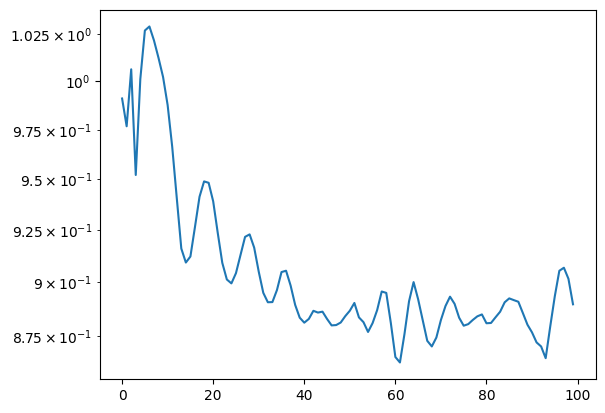

In [52]:
for i in (pbar := tqdm.tqdm(range(total_steps))):  
    loss = train_step(model, optimizer, loss_fn)

    losses.append(loss)
    pbar.set_description(f"Loss: {loss:.4f}")

fig, ax = plt.subplots()
ax.plot(losses)
ax.set(yscale="log")

### checkpointing

In [53]:
# # see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/hpm_mlp_sim.jx")
# checkpointer = ocp.StandardCheckpointer()
# print(os.getcwd())

In [54]:
# _, params = nnx.split(model)
# checkpointer.save(checkpoint_file, params, force=True)

In [55]:
# abstract_model = nnx.eval_shape(lambda: model)
# graphdef, abstract_params = nnx.split(abstract_model)

# params = checkpointer.restore(checkpoint_file, abstract_params)
# model = nnx.merge(graphdef, params)

# run the simulation

In [56]:
pm_ode = hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, "odeint", gravity_only=True)

# res = odeint(pm_ode, [dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]], scales, {"gas_latent": jnp.ones(parts_per_dim**3)}, rtol=1e-5, atol=1e-5)
res = odeint(pm_ode, [dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]], scales, {}, rtol=1e-5, atol=1e-5)
pm_dm_poss, pm_dm_vels, pm_gas_poss, pm_gas_vels = res[0], res[1], res[2], res[3]

In [57]:
hpm_ode = hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, "odeint", architecture=architecture)
# hpm_ode = hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, "odeint", force_type="gnn", edges=edges)
# hpm_ode = lambda state, scale: gnn_hpm_ode(scale, state, None)

# res = odeint(hpm_ode, [dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]], scales, {"gas_latent": jnp.ones(parts_per_dim**3)}, rtol=1e-5, atol=1e-5, mxstep=20)
res = odeint(hpm_ode, [dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]], scales, {}, rtol=1e-5, atol=1e-5, mxstep=20)
hpm_dm_poss, hpm_dm_vels, hpm_gas_poss, hpm_gas_vels = res[0], res[1], res[2], res[3]

In [58]:
# res = diffeqsolve(
#         terms=ODETerm(hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, integrator_type="diffrax", precomputed_edges=edges, architecture=architecture)),
#         solver=LeapfrogMidpoint(),
#         t0=scales[0],
#         t1=scales[-1],
#         dt0=0.01,
#         y0=jnp.stack([dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]], axis=0),
#         saveat=SaveAt(ts=scales),
#         args={"gas_latent": jnp.ones(parts_per_dim**3)},
#         max_steps=100,
#         stepsize_controller=ConstantStepSize(),
#     )
# res = res.ys
# res = jnp.transpose(res, (1,0,2,3))

# hpm_dm_poss, hpm_dm_vels, hpm_gas_poss, hpm_gas_vels = res[0], res[1], res[2], res[3]

100%|██████████| 9/9 [00:30<00:00,  3.38s/it]


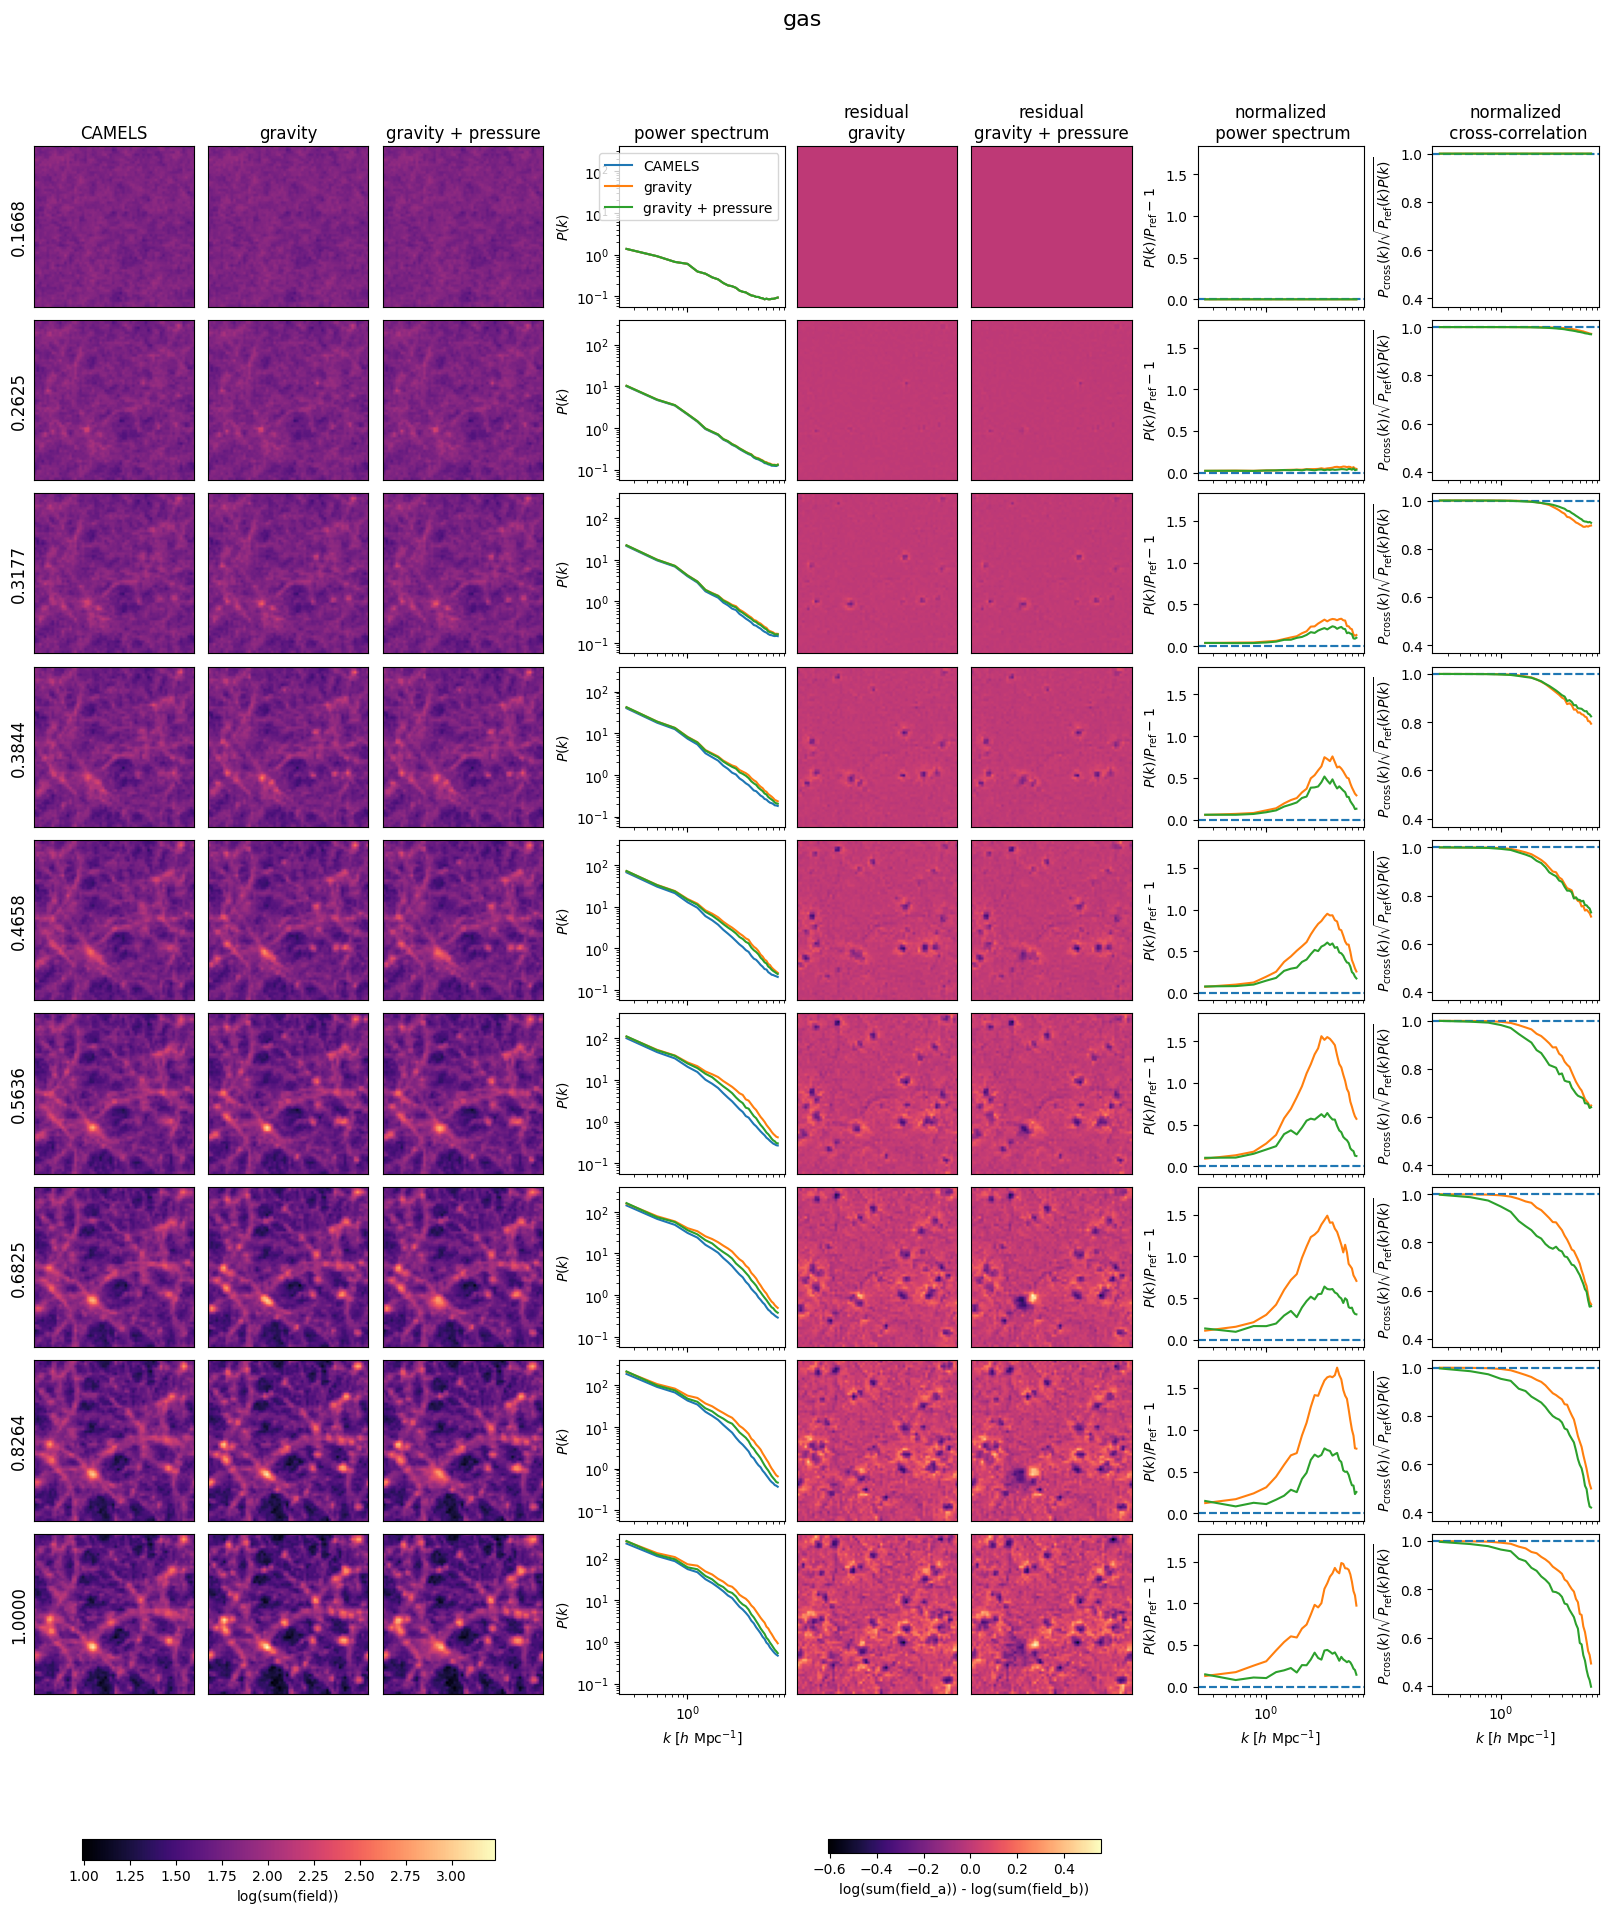

In [59]:
plotting.compare_particle_evolution(
    mesh_shape, 
    scales, 
    jnp.stack([gas_poss, pm_gas_poss, hpm_gas_poss], axis=0), 
    title="gas",
    col_titles=["CAMELS", "gravity", "gravity + pressure"],
    include_pk=True,
    include_reference=True,
)